In [ ]:
import torch 
import torch .nn .functional as F 
from transformers import AutoTokenizer ,AutoModelForSequenceClassification 

device =torch .device ("cuda"if torch .cuda .is_available ()else "cpu")
print (f"L'exécution se fera sur : {device }\n")


model_a_name ="distilbert-base-uncased-finetuned-sst-2-english"
print (f"Chargement de la Cible A ({model_a_name })...")

tokenizer_a =AutoTokenizer .from_pretrained (model_a_name )
model_a =AutoModelForSequenceClassification .from_pretrained (model_a_name ).to (device )
model_a .eval ()

model_b_name ="nlptown/bert-base-multilingual-uncased-sentiment"
print (f"Chargement de la Cible B ({model_b_name })...")

tokenizer_b =AutoTokenizer .from_pretrained (model_b_name )
model_b =AutoModelForSequenceClassification .from_pretrained (model_b_name ).to (device )
model_b .eval ()

print ("\n[OK] Tous les modèles sont chargés en mémoire et prêts.")

In [1]:
import torch 
import torch .nn .functional as F 
from transformers import AutoTokenizer ,AutoModelForSequenceClassification 

device =torch .device ("cuda"if torch .cuda .is_available ()else "cpu")
print (f"L'exécution se fera sur : {device }\n")


model_a_name ="distilbert-base-uncased-finetuned-sst-2-english"
print (f"Chargement de la Cible A ({model_a_name })...")

tokenizer_a =AutoTokenizer .from_pretrained (model_a_name )
model_a =AutoModelForSequenceClassification .from_pretrained (model_a_name ).to (device )
model_a .eval ()

model_b_name ="nlptown/bert-base-multilingual-uncased-sentiment"
print (f"Chargement de la Cible B ({model_b_name })...")

tokenizer_b =AutoTokenizer .from_pretrained (model_b_name )
model_b =AutoModelForSequenceClassification .from_pretrained (model_b_name ).to (device )
model_b .eval ()

print ("\n[OK] Tous les modèles sont chargés en mémoire et prêts.")

/Users/macbookair/Documents/stage_oulu/codes/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


L'exécution se fera sur : cpu

Chargement de la Cible A (distilbert-base-uncased-finetuned-sst-2-english)...
Chargement de la Cible B (nlptown/bert-base-multilingual-uncased-sentiment)...

[OK] Tous les modèles sont chargés en mémoire et prêts.


In [2]:
text_original ="The cast performed brilliantly in this cinematic masterpiece."

def predict_sentiment (text ,model ,tokenizer ,is_multilingual =False ):
    """Fonction utilitaire pour obtenir la prédiction et la confiance d'un modèle"""

    inputs =tokenizer (text ,return_tensors ="pt",truncation =True ,padding =True ).to (device )

    with torch .no_grad ():
        outputs =model (**inputs )
        probabilities =F .softmax (outputs .logits ,dim =-1 ).squeeze ()


    confidence ,class_idx =torch .max (probabilities ,dim =0 )
    confidence =confidence .item ()
    class_idx =class_idx .item ()

    if is_multilingual :

        label =f"{class_idx +1 } Étoile(s)"
    else :

        label ="POSITIF"if class_idx ==1 else "NÉGATIF"

    return label ,confidence 


print ("--- PRÉDICTIONS INITIALES ---")
label_a ,conf_a =predict_sentiment (text_original ,model_a ,tokenizer_a ,is_multilingual =False )
print (f"[Cible A - DistilBERT] Résultat : {label_a } | Confiance : {conf_a :.4f}")

label_b ,conf_b =predict_sentiment (text_original ,model_b ,tokenizer_b ,is_multilingual =True )
print (f"[Cible B - BERT Multi] Résultat : {label_b } | Confiance : {conf_b :.4f}")

--- PRÉDICTIONS INITIALES ---
[Cible A - DistilBERT] Résultat : POSITIF | Confiance : 0.9999
[Cible B - BERT Multi] Résultat : 5 Étoile(s) | Confiance : 0.8402


In [3]:
import textattack 
from textattack .models .wrappers import HuggingFaceModelWrapper 
from textattack .attack_recipes import TextFoolerJin2019 ,PWWSRen2019 

print ("--- ÉTAPE 2 : Création des Wrappers ---")


wrapper_a =HuggingFaceModelWrapper (model_a ,tokenizer_a )
print ("[OK] Wrapper A (DistilBERT) prêt.")

wrapper_b =HuggingFaceModelWrapper (model_b ,tokenizer_b )
print ("[OK] Wrapper B (BERT Multi) prêt.")


print ("\n--- ÉTAPE 3 : Initialisation des Moteurs d'Attaque ---")





print ("Construction des attaques pour la Cible A...")
attack_tf_a =TextFoolerJin2019 .build (wrapper_a )
attack_pwws_a =PWWSRen2019 .build (wrapper_a )


print ("Construction des attaques pour la Cible B...")
attack_tf_b =TextFoolerJin2019 .build (wrapper_b )
attack_pwws_b =PWWSRen2019 .build (wrapper_b )

print ("\n[OK] Les 4 moteurs d'attaque (TextFooler et PWWS pour chaque modèle) sont armés.")

2026-05-25 08:00:26.892104: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


--- ÉTAPE 2 : Création des Wrappers ---
[OK] Wrapper A (DistilBERT) prêt.
[OK] Wrapper B (BERT Multi) prêt.

--- ÉTAPE 3 : Initialisation des Moteurs d'Attaque ---
Construction des attaques pour la Cible A...


textattack: Unknown if model of class <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/macbookair/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
textattack: Unknown if model of class <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Unknown if model of class <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/macbo

Construction des attaques pour la Cible B...

[OK] Les 4 moteurs d'attaque (TextFooler et PWWS pour chaque modèle) sont armés.


In [4]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/macbookair/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [5]:
import textattack 

print ("--- ÉTAPE 4 : Exécution de l'Attaque (Cible A - DistilBERT) ---")



texte_test ="The cast performed brilliantly in this cinematic masterpiece."
label_vrai =1 


dataset_a =textattack .datasets .Dataset ([(texte_test ,label_vrai )])


attack_args =textattack .AttackArgs (
num_examples =1 ,
log_to_csv ="resultats_phase1.csv",
checkpoint_interval =5 ,
disable_stdout =False 
)


print ("\n[Lancement de l'attaque TextFooler...]")
attacker_tf_a =textattack .Attacker (attack_tf_a ,dataset_a ,attack_args )


results_tf_a =attacker_tf_a .attack_dataset ()

print ("\n[OK] Attaque terminée. Les résultats sont sauvegardés dans 'resultats_phase1.csv'.")

textattack: Logging to CSV at path resultats_phase1.csv


--- ÉTAPE 4 : Exécution de l'Attaque (Cible A - DistilBERT) ---

[Lancement de l'attaque TextFooler...]
Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  WordSwapEmbedding(
    (max_candidates):  50
    (embedding):  WordEmbedding
  )
  (constraints): 
    (0): WordEmbeddingDistance(
        (embedding):  WordEmbedding
        (min_cos_sim):  0.5
        (cased):  False
        (include_unknown_words):  True
        (compare_against_original):  True
      )
    (1): PartOfSpeech(
        (tagger_type):  nltk
        (tagset):  universal
        (allow_verb_noun_swap):  True
        (compare_against_original):  True
      )
    (2): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.840845057
        (window_size):  15
        (skip_text_shorter_than_window):  True
        (compare_against_original):  False
      )
    (3): RepeatModification
    (4): StopwordModificatio

  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

textattack: Unknown if model of class <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.


--- ÉTAPE 5 : Diagnostic Complet (ASR, Confiance, Phrases) ---
Lancement de 9 attaques TextFooler sur 5 phrases...
Impression des phrases réussies activée.



[Succeeded / Failed / Skipped / Total] 4 / 1 / 0 / 5: 100%|██████████| 5/5 [07:26<00:00, 89.22s/it] 
textattack: Unknown if model of class <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.





--- Test [USE=0.5 | CosSim=0.5] ---

[SUCCÈS D'ATTAQUE VISIBLE]
Orig: The cast performed brilliantly in this cinematic masterpiece.
Pert: Both thrown executed eloquently in this cinematographic shaft.

[SUCCÈS D'ATTAQUE VISIBLE]
Orig: This movie is a complete waste of time and money.
Pert: This cinematography is a complete jingles of time and money.

[SUCCÈS D'ATTAQUE VISIBLE]
Orig: The acting was terrible and the plot was boring.
Pert: The acting was terrible and the plots was piercing.

[SUCCÈS D'ATTAQUE VISIBLE]
Orig: A visually stunning film with a great soundtrack.
Pert: another visually magnifique film with a gargantuan cassette.


[Succeeded / Failed / Skipped / Total] 4 / 1 / 0 / 5: 100%|██████████| 5/5 [04:20<00:00, 52.05s/it]
textattack: Unknown if model of class <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.


...




--- Test [USE=0.9 | CosSim=0.5] ---


[Succeeded / Failed / Skipped / Total] 0 / 5 / 0 / 5: 100%|██████████| 5/5 [01:09<00:00, 13.85s/it]
textattack: Unknown if model of class <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.





--- Test [USE=0.9 | CosSim=0.7] ---


[Succeeded / Failed / Skipped / Total] 0 / 5 / 0 / 5: 100%|██████████| 5/5 [00:38<00:00,  7.71s/it]





--- Test [USE=0.9 | CosSim=0.9] ---

[OK] Tests terminés. Génération des graphiques...


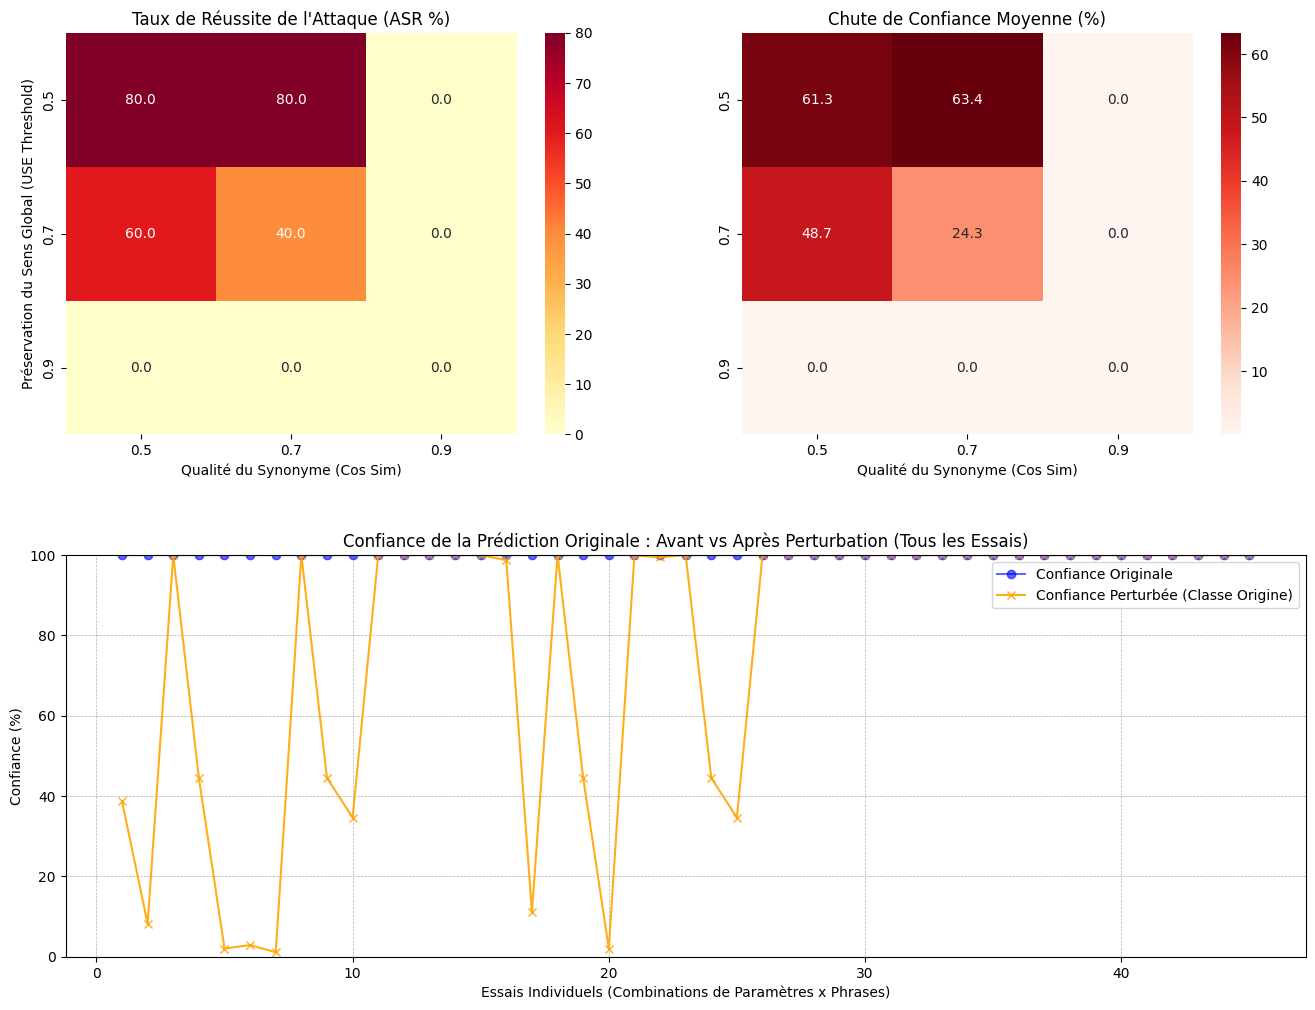

In [ ]:
import textattack 
from textattack .constraints .semantics import WordEmbeddingDistance 
from textattack .constraints .semantics .sentence_encoders import UniversalSentenceEncoder 
import matplotlib .pyplot as plt 
import seaborn as sns 
import numpy as np 
import torch 

print ("--- ÉTAPE 5 : Diagnostic Complet (ASR, Confiance, Phrases) ---")


phrases_test =[
("The cast performed brilliantly in this cinematic masterpiece.",1 ),
("This movie is a complete waste of time and money.",0 ),
("An absolutely wonderful and touching story.",1 ),
("The acting was terrible and the plot was boring.",0 ),
("A visually stunning film with a great soundtrack.",1 )
]
dataset_multi =textattack .datasets .Dataset (phrases_test )


cos_sim_values =[0.5 ,0.7 ,0.9 ]
use_thresholds =[0.5 ,0.7 ,0.9 ]


asr_matrix =np .zeros ((len (use_thresholds ),len (cos_sim_values )))
conf_drop_matrix =np .zeros ((len (use_thresholds ),len (cos_sim_values )))


all_orig_confidences =[]
all_pert_confidences =[]

attack_args_silent =textattack .AttackArgs (
num_examples =len (phrases_test ),silent =True ,disable_stdout =True 
)

print (f"Lancement de {len (cos_sim_values )*len (use_thresholds )} attaques TextFooler sur {len (phrases_test )} phrases...")
print ("Impression des phrases réussies activée.\n")


for i ,use_val in enumerate (use_thresholds ):
    for j ,cos_val in enumerate (cos_sim_values ):


        attack_grid =textattack .attack_recipes .TextFoolerJin2019 .build (wrapper_a )


        for k ,constraint in enumerate (attack_grid .constraints ):
            if isinstance (constraint ,WordEmbeddingDistance ):
                attack_grid .constraints [k ]=WordEmbeddingDistance (min_cos_sim =cos_val )
            elif isinstance (constraint ,UniversalSentenceEncoder ):
                attack_grid .constraints [k ]=UniversalSentenceEncoder (
                threshold =use_val ,metric ="angular",window_size =15 
                )

        attacker =textattack .Attacker (attack_grid ,dataset_multi ,attack_args_silent )
        results =attacker .attack_dataset ()

        print (f"\n--- Test [USE={use_val } | CosSim={cos_val }] ---")

        successes =0 
        total_drop =0.0 
        valide_results_count =0 


        for r in results :
            if r .__class__ .__name__ =="SuccessfulAttackResult":
                successes +=1 

                print (f"\n[SUCCÈS D'ATTAQUE VISIBLE]")
                print (f"Orig: {r .original_result .attacked_text .text }")
                print (f"Pert: {r .perturbed_result .attacked_text .text }")

            if r .__class__ .__name__ !="SkippedAttackResult":
                valide_results_count +=1 
                orig_class =r .original_result .output 


                orig_conf =r .original_result .raw_output [orig_class ].item ()*100 
                pert_conf =r .perturbed_result .raw_output [orig_class ].item ()*100 
                all_orig_confidences .append (orig_conf )
                all_pert_confidences .append (pert_conf )

                total_drop +=(orig_conf -pert_conf )

        asr =(successes /len (phrases_test ))*100 
        avg_drop =(total_drop /valide_results_count )if valide_results_count >0 else 0 
        asr_matrix [i ,j ]=asr 
        conf_drop_matrix [i ,j ]=avg_drop 


print ("\n[OK] Tests terminés. Génération des graphiques...")

fig =plt .figure (figsize =(16 ,12 ))
grid =plt .GridSpec (2 ,2 ,hspace =0.3 ,wspace =0.2 )


ax_asr =fig .add_subplot (grid [0 ,0 ])
sns .heatmap (asr_matrix ,annot =True ,fmt =".1f",cmap ="YlOrRd",
xticklabels =cos_sim_values ,yticklabels =use_thresholds ,ax =ax_asr )
ax_asr .set_title ("Taux de Réussite de l'Attaque (ASR %)")
ax_asr .set_xlabel ("Qualité du Synonyme (Cos Sim)")
ax_asr .set_ylabel ("Préservation du Sens Global (USE Threshold)")


ax_drop =fig .add_subplot (grid [0 ,1 ])
sns .heatmap (conf_drop_matrix ,annot =True ,fmt =".1f",cmap ="Reds",
xticklabels =cos_sim_values ,yticklabels =use_thresholds ,ax =ax_drop )
ax_drop .set_title ("Chute de Confiance Moyenne (%)")
ax_drop .set_xlabel ("Qualité du Synonyme (Cos Sim)")
ax_drop .set_ylabel ("")



ax_line =fig .add_subplot (grid [1 ,:])
trials =np .arange (1 ,len (all_orig_confidences )+1 )
ax_line .plot (trials ,all_orig_confidences ,label ='Confiance Originale',color ='blue',marker ='o',alpha =0.6 )
ax_line .plot (trials ,all_pert_confidences ,label ='Confiance Perturbée (Classe Origine)',color ='orange',marker ='x',alpha =0.9 )

ax_line .set_title ("Confiance de la Prédiction Originale : Avant vs Après Perturbation (Tous les Essais)")
ax_line .set_xlabel ("Essais Individuels (Combinations de Paramètres x Phrases)")
ax_line .set_ylabel ("Confiance (%)")
ax_line .set_ylim (0 ,100 )
ax_line .legend ()
ax_line .grid (True ,which ='both',linestyle ='--',linewidth =0.5 )

plt .show ()

textattack: Unknown if model of class <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.


--- ÉTAPE 6 : Traçage complet (CSV + Graphe) ---

[Démarrage de la recherche (silencieux)...]


[Succeeded / Failed / Skipped / Total] 1 / 0 / 0 / 1: 100%|██████████| 1/1 [00:33<00:00, 33.25s/it]




[OK] 100 tentatives évaluées !
[OK] Historique sauvegardé dans 'tentatives_espion.csv'.


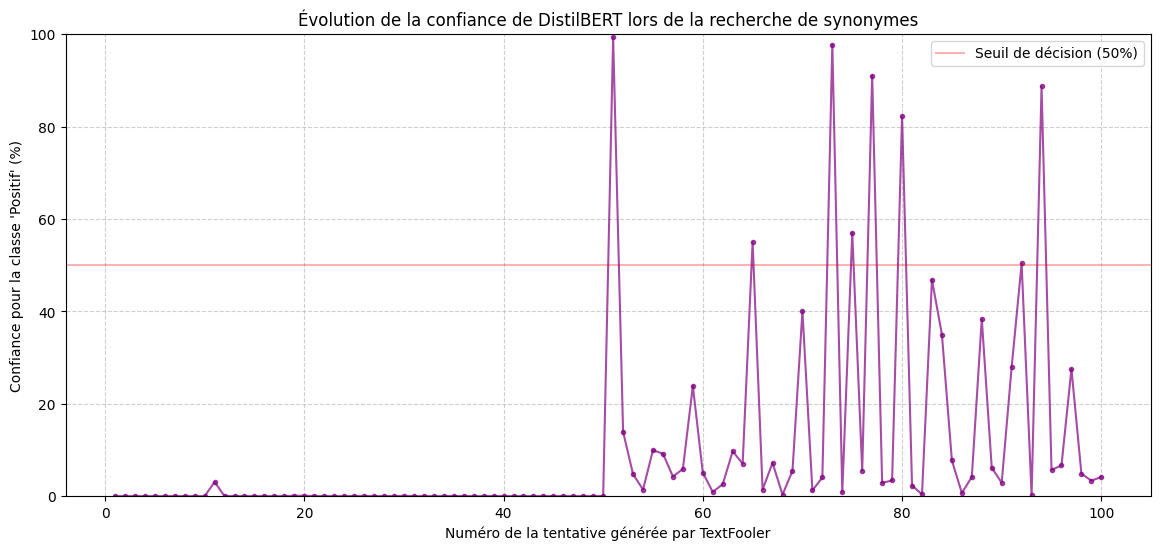

In [ ]:
import textattack 
from textattack .constraints import Constraint 
from textattack .constraints .semantics import WordEmbeddingDistance 
from textattack .constraints .semantics .sentence_encoders import UniversalSentenceEncoder 
import torch 
import torch .nn .functional as F 
import matplotlib .pyplot as plt 
import csv 

print ("--- ÉTAPE 6 : Traçage complet (CSV + Graphe) ---")

class SpyConstraint (Constraint ):
    def __init__ (self ,model ,tokenizer ):
        super ().__init__ (compare_against_original =False )
        self .seen_candidates =set ()
        self .history =[]
        self .model =model 
        self .tokenizer =tokenizer 
        self .device =next (model .parameters ()).device 

    def _check_constraint (self ,transformed_text ,reference_text ):
        texte =transformed_text .text 
        if texte not in self .seen_candidates :

            inputs =self .tokenizer (texte ,return_tensors ="pt",truncation =True ,padding =True ).to (self .device )
            with torch .no_grad ():
                outputs =self .model (**inputs )
                probs =F .softmax (outputs .logits ,dim =-1 ).squeeze ()

            conf_positif =probs [1 ].item ()*100 


            self .history .append ((texte ,conf_positif ))
            self .seen_candidates .add (texte )

        return True 


phrase_unique =[("The acting was terrible and the plot was boring",0 )]
dataset_single =textattack .datasets .Dataset (phrase_unique )
attack_spy =textattack .attack_recipes .TextFoolerJin2019 .build (wrapper_a )

for i ,constraint in enumerate (attack_spy .constraints ):
    if isinstance (constraint ,WordEmbeddingDistance ):
        attack_spy .constraints [i ]=WordEmbeddingDistance (min_cos_sim =0.7 )
    elif isinstance (constraint ,UniversalSentenceEncoder ):
        attack_spy .constraints [i ]=UniversalSentenceEncoder (threshold =0.7 ,metric ="angular",window_size =15 )


attack_spy .constraints .insert (0 ,espion :=SpyConstraint (model_a ,tokenizer_a ))


print ("\n[Démarrage de la recherche (silencieux)...]")
attack_args_single =textattack .AttackArgs (num_examples =1 ,disable_stdout =True ,silent =True )
attacker_single =textattack .Attacker (attack_spy ,dataset_single ,attack_args_single )
results_single =attacker_single .attack_dataset ()

print (f"[OK] {len (espion .history )} tentatives évaluées !")


csv_filename ="tentatives_espion.csv"
with open (csv_filename ,mode ='w',newline ='',encoding ='utf-8')as f :
    writer =csv .writer (f )
    writer .writerow (["Essai","Confiance_Positif","Texte"])
    for i ,(texte ,conf )in enumerate (espion .history ):
        writer .writerow ([i +1 ,round (conf ,2 ),texte ])

print (f"[OK] Historique sauvegardé dans '{csv_filename }'.")


essais =range (1 ,len (espion .history )+1 )
confiances =[conf for texte ,conf in espion .history ]

plt .figure (figsize =(14 ,6 ))
plt .plot (essais ,confiances ,marker ='.',linestyle ='-',color ='purple',alpha =0.7 )
plt .title ("Évolution de la confiance de DistilBERT lors de la recherche de synonymes")
plt .xlabel ("Numéro de la tentative générée par TextFooler")
plt .ylabel ("Confiance pour la classe 'Positif' (%)")
plt .ylim (0 ,100 )
plt .grid (True ,linestyle ='--',alpha =0.6 )


plt .axhline (y =50 ,color ='red',linestyle ='-',alpha =0.3 ,label ="Seuil de décision (50%)")
plt .legend ()

plt .show ()

In [ ]:
import torch 
import torch .nn .functional as F 
from captum .attr import LayerIntegratedGradients 
from captum .attr import visualization as viz 

print ("--- ÉTAPE 7 : XAI Diagnostic (Saliency Maps avec Integrated Gradients) ---")



text_original ="The acting was terrible and the plot was boring."
text_perturbed ="I don't think that the acting was not terrible and not boring."

true_label =1 


def predict_forward (inputs ,attention_mask =None ):
    return model_a (inputs ,attention_mask =attention_mask ).logits 


lig =LayerIntegratedGradients (predict_forward ,model_a .distilbert .embeddings .word_embeddings )

def generate_explanation (text ,target_class ):
    model_a .zero_grad ()


    inputs =tokenizer_a (text ,return_tensors ="pt",truncation =True ,padding =True ).to (device )
    input_ids =inputs ["input_ids"]
    attention_mask =inputs ["attention_mask"]


    ref_token_id =tokenizer_a .pad_token_id 
    baseline =torch .full_like (input_ids ,ref_token_id ).to (device )


    attributions ,delta =lig .attribute (
    inputs =input_ids ,
    baselines =baseline ,
    additional_forward_args =(attention_mask ,),
    target =target_class ,
    return_convergence_delta =True 
    )


    attributions =attributions .sum (dim =-1 ).squeeze (0 )
    attributions =attributions /torch .norm (attributions )


    with torch .no_grad ():
        logits =predict_forward (input_ids ,attention_mask )
        probs =F .softmax (logits ,dim =-1 ).squeeze (0 )
        pred_class =torch .argmax (probs ).item ()
        pred_prob =probs [pred_class ].item ()


    tokens =tokenizer_a .convert_ids_to_tokens (input_ids [0 ])


    vis_record =viz .VisualizationDataRecord (
    word_attributions =attributions .cpu ().detach ().numpy (),
    pred_prob =pred_prob ,
    pred_class ="Positif"if pred_class ==1 else "Négatif",
    true_class ="Positif"if target_class ==1 else "Négatif",
    attr_class ="Positif",
    attr_score =attributions .sum ().item (),
    raw_input_ids =tokens ,
    convergence_score =delta .item ()
    )
    return vis_record 

print ("[Calcul des gradients mathématiques en cours...]")


vis_original =generate_explanation (text_original ,true_label )
vis_perturbed =generate_explanation (text_perturbed ,true_label )


print ("\n[OK] Affichage des Saliency Maps :")
_ =viz .visualize_text ([vis_original ,vis_perturbed ])

--- ÉTAPE 7 : XAI Diagnostic (Saliency Maps avec Integrated Gradients) ---
[Calcul des gradients mathématiques en cours...]

[OK] Affichage des Saliency Maps :


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
Positif,Négatif (1.00),Positif,-2.83,[CLS] the acting was terrible and the plot was boring . [SEP]
Positif,Positif (1.00),Positif,1.57,[CLS] i don ' t think that the acting was not terrible and not boring . [SEP]


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/macbookair/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import nltk 
from nltk .tokenize import word_tokenize 
from captum .attr import visualization as viz 


nltk .download ('punkt')
nltk .download ('punkt_tab')
nltk .download ('averaged_perceptron_tagger_eng')

print ("--- ÉTAPE 8 : Générateur d'Attaques Syntaxiques Automatisé ---")

def generate_complex_negation (text ):
    """
    Algorithme qui ajoute 'not' devant les adjectifs 
    et encapsule la phrase dans une négation globale.
    """
    tokens =word_tokenize (text )
    tags =nltk .pos_tag (tokens )

    new_tokens =[]
    for i ,(word ,tag )in enumerate (tags ):


        if tag .startswith ('JJ')and (i ==0 or tokens [i -1 ].lower ()not in ['not','no','never']):
            new_tokens .append ('not')
        new_tokens .append (word )


    perturbed_core =" ".join (new_tokens ).replace (" .",".").replace (" ,",",")


    prefix ="I don't think that "


    perturbed_core =perturbed_core [0 ].lower ()+perturbed_core [1 :]

    return prefix +perturbed_core 


phrases_a_tester =[
("The acting was terrible and the plot was boring.",0 ),
("A visually stunning film with a great soundtrack.",1 ),
("This movie is a complete waste of time.",0 ),
("The actors performed brilliantly.",1 )
]

visualizations =[]

print ("[Génération des attaques et calcul des gradients XAI...]\n")


for original_text ,true_label in phrases_test :


    attacked_text =generate_complex_negation (original_text )


    vis_orig =generate_explanation (original_text ,true_label )
    visualizations .append (vis_orig )


    vis_attack =generate_explanation (attacked_text ,true_label )
    visualizations .append (vis_attack )

    print (f"Original : {original_text }")
    print (f"Attaqué  : {attacked_text }\n")


print ("[OK] Affichage du rapport XAI comparatif :")
_ =viz .visualize_text (visualizations )

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/macbookair/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/macbookair/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/macbookair/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


--- ÉTAPE 8 : Générateur d'Attaques Syntaxiques Automatisé ---
[Génération des attaques et calcul des gradients XAI...]

Original : The cast performed brilliantly in this cinematic masterpiece.
Attaqué  : I don't think that the cast performed brilliantly in this not cinematic masterpiece.

Original : This movie is a complete waste of time and money.
Attaqué  : I don't think that this movie is a not complete waste of time and money.

Original : An absolutely wonderful and touching story.
Attaqué  : I don't think that an absolutely not wonderful and not touching story.

Original : The acting was terrible and the plot was boring.
Attaqué  : I don't think that the acting was not terrible and the plot was boring.

Original : A visually stunning film with a great soundtrack.
Attaqué  : I don't think that a visually not stunning film with a not great soundtrack.

[OK] Affichage du rapport XAI comparatif :


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
Positif,Positif (1.00),Positif,2.62,[CLS] the cast performed brilliant ##ly in this cinematic masterpiece . [SEP]
Positif,Négatif (1.00),Positif,-0.68,[CLS] i don ' t think that the cast performed brilliant ##ly in this not cinematic masterpiece . [SEP]
Négatif,Négatif (1.00),Positif,2.59,[CLS] this movie is a complete waste of time and money . [SEP]
Négatif,Négatif (0.99),Positif,1.23,[CLS] i don ' t think that this movie is a not complete waste of time and money . [SEP]
Positif,Positif (1.00),Positif,2.67,[CLS] an absolutely wonderful and touching story . [SEP]
Positif,Négatif (1.00),Positif,-3.16,[CLS] i don ' t think that an absolutely not wonderful and not touching story . [SEP]
Négatif,Négatif (1.00),Positif,2.84,[CLS] the acting was terrible and the plot was boring . [SEP]
Négatif,Négatif (1.00),Positif,2.82,[CLS] i don ' t think that the acting was not terrible and the plot was boring . [SEP]
Positif,Positif (1.00),Positif,2.86,[CLS] a visually stunning film with a great soundtrack . [SEP]
Positif,Négatif (1.00),Positif,-1.51,[CLS] i don ' t think that a visually not stunning film with a not great soundtrack . [SEP]


In [ ]:
import textattack 

print ("--- ÉTAPE 9 : Attaque PWWS (Probability Weighted Word Saliency) ---")


phrases_test =[
("The acting was terrible and the plot was boring.",0 ),
("A visually stunning film with a great soundtrack.",1 ),
("This movie is a complete waste of time and money.",0 ),
("The cast performed brilliantly in this cinematic masterpiece.",1 )
]
dataset_pwws =textattack .datasets .Dataset (phrases_test )


attack_pwws =textattack .attack_recipes .PWWSRen2019 .build (wrapper_a )


print ("\n[Configuration de l'algorithme PWWS] :")
print (f"- Méthode de recherche : {attack_pwws .search_method .__class__ .__name__ }")
print (f"- Transformation (Synonymes) : {attack_pwws .transformation .__class__ .__name__ }\n")


attack_args_pwws =textattack .AttackArgs (
num_examples =len (phrases_test ),
disable_stdout =False ,
silent =True 
)

print ("[Lancement de l'attaque ciblée PWWS...]")
attacker_pwws =textattack .Attacker (attack_pwws ,dataset_pwws ,attack_args_pwws )
results_pwws =attacker_pwws .attack_dataset ()

print ("\n[OK] Attaque PWWS terminée.")

--- ÉTAPE 9 : Attaque PWWS (Probability Weighted Word Saliency) ---


[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/macbookair/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
textattack: Unknown if model of class <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.



[Configuration de l'algorithme PWWS] :
- Méthode de recherche : GreedyWordSwapWIR
- Transformation (Synonymes) : WordSwapWordNet

[Lancement de l'attaque ciblée PWWS...]


 25%|██▌       | 1/4 [00:47<02:21, 47.30s/it]

--------------------------------------------- Result 1 ---------------------------------------------


...

--------------------------------------------- Result 2 ---------------------------------------------
[[1 (100%)]] --> [[0 (100%)]]

A visually [[stunning]] film with a [[great]] soundtrack.

A visually [[stun]] film with a [[bully]] soundtrack.


[Succeeded / Failed / Skipped / Total] 3 / 0 / 0 / 3:  75%|███████▌  | 3/4 [02:07<00:42, 42.49s/it]

--------------------------------------------- Result 3 ---------------------------------------------
[[0 (100%)]] --> [[1 (100%)]]

This movie is a complete [[waste]] of time and money.

This movie is a complete [[ravage]] of time and money.


[Succeeded / Failed / Skipped / Total] 3 / 1 / 0 / 4: 100%|██████████| 4/4 [02:46<00:00, 41.67s/it]

--------------------------------------------- Result 4 ---------------------------------------------
[[1 (100%)]] --> [[[FAILED]]]

The cast performed brilliantly in this cinematic masterpiece.

+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 3      |
| Number of failed attacks:     | 1      |
| Number of skipped attacks:    | 0      |
| Original accuracy:            | 100.0% |
| Accuracy under attack:        | 25.0%  |
| Attack success rate:          | 75.0%  |
| Average perturbed word %:     | 19.07% |
| Average num. words per input: | 8.75   |
| Avg num queries:              | 88.5   |
+-------------------------------+--------+

[OK] Attaque PWWS terminée.


In [ ]:
import textattack 
from textattack .transformations import WordSwapEmbedding 
from textattack .constraints .semantics import WordEmbeddingDistance 
from textattack .constraints .semantics .sentence_encoders import UniversalSentenceEncoder 
from textattack .constraints .grammaticality import PartOfSpeech 

print ("--- ÉTAPE 10 : Création de PWWS 2.0 (Hybride) ---")


attack_pwws_custom =textattack .attack_recipes .PWWSRen2019 .build (wrapper_a )



attack_pwws_custom .transformation =WordSwapEmbedding (max_candidates =50 )



attack_pwws_custom .constraints .append (
WordEmbeddingDistance (min_cos_sim =0.7 ,compare_against_original =True )
)
attack_pwws_custom .constraints .append (
UniversalSentenceEncoder (threshold =0.7 ,metric ="angular",window_size =15 )
)
attack_pwws_custom .constraints .append (
PartOfSpeech (allow_verb_noun_swap =False )
)

print ("[OK] PWWS 2.0 assemblé : Ciblage mathématique + Synonymes sous haute sécurité.\n")


attack_args_custom =textattack .AttackArgs (
num_examples =len (phrases_test ),
disable_stdout =False ,
silent =True 
)

print ("[Lancement de l'attaque PWWS 2.0...]")
attacker_custom =textattack .Attacker (attack_pwws_custom ,dataset_pwws ,attack_args_custom )
results_custom =attacker_custom .attack_dataset ()

print ("\n[OK] Attaque PWWS 2.0 terminée.")

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/macbookair/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
textattack: Unknown if model of class <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.


--- ÉTAPE 10 : Création de PWWS 2.0 (Hybride) ---
[OK] PWWS 2.0 assemblé : Ciblage mathématique + Synonymes sous haute sécurité.

[Lancement de l'attaque PWWS 2.0...]


[Succeeded / Failed / Skipped / Total] 1 / 0 / 0 / 1:  25%|██▌       | 1/4 [01:09<03:27, 69.03s/it]

--------------------------------------------- Result 1 ---------------------------------------------
[[0 (100%)]] --> [[1 (99%)]]

The acting was [[terrible]] and the plot was [[boring]].

The acting was [[abysmal]] and the plot was [[piercing]].


[Succeeded / Failed / Skipped / Total] 2 / 0 / 0 / 2:  50%|█████     | 2/4 [02:54<02:54, 87.36s/it]

--------------------------------------------- Result 2 ---------------------------------------------
[[1 (100%)]] --> [[0 (56%)]]

A visually [[stunning]] film with a [[great]] soundtrack.

A visually [[stun]] film with a [[big]] soundtrack.


[Succeeded / Failed / Skipped / Total] 2 / 1 / 0 / 3:  75%|███████▌  | 3/4 [04:01<01:20, 80.65s/it]

--------------------------------------------- Result 3 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

This movie is a complete waste of time and money.


[Succeeded / Failed / Skipped / Total] 2 / 2 / 0 / 4: 100%|██████████| 4/4 [04:50<00:00, 72.66s/it]

--------------------------------------------- Result 4 ---------------------------------------------
[[1 (100%)]] --> [[[FAILED]]]

The cast performed brilliantly in this cinematic masterpiece.

+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 2      |
| Number of failed attacks:     | 2      |
| Number of skipped attacks:    | 0      |
| Original accuracy:            | 100.0% |
| Accuracy under attack:        | 50.0%  |
| Attack success rate:          | 50.0%  |
| Average perturbed word %:     | 23.61% |
| Average num. words per input: | 8.75   |
| Avg num queries:              | 128.75 |
+-------------------------------+--------+

[OK] Attaque PWWS 2.0 terminée.


In [ ]:
import textattack 
from textattack .transformations import (
CompositeTransformation ,
WordSwapNeighboringCharacterSwap ,
WordSwapRandomCharacterDeletion ,
WordSwapRandomCharacterInsertion ,
WordSwapRandomCharacterSubstitution 
)
from textattack .search_methods import GreedyWordSwapWIR 
from textattack .constraints .pre_transformation import RepeatModification ,StopwordModification 
from textattack .constraints .pre_transformation .min_word_length import MinWordLength 
from textattack .goal_functions import UntargetedClassification 

print ("--- ÉTAPE 11 : Attaque Typographique (Fautes de Frappe) ---")


transformation_typo =CompositeTransformation ([
WordSwapNeighboringCharacterSwap (),
WordSwapRandomCharacterDeletion (),
WordSwapRandomCharacterInsertion (),
WordSwapRandomCharacterSubstitution ()
])


search_method_typo =GreedyWordSwapWIR (wir_method ="unk")


constraints_typo =[
RepeatModification (),
StopwordModification (),
MinWordLength (4 )
]


goal_function_typo =UntargetedClassification (wrapper_a )


attack_typo =textattack .Attack (
goal_function =goal_function_typo ,
constraints =constraints_typo ,
transformation =transformation_typo ,
search_method =search_method_typo 
)

print ("[OK] Générateur de fautes de frappe assemblé. Prêt à cibler les mots-clés.\n")


attack_args_typo =textattack .AttackArgs (
num_examples =len (phrases_test ),
disable_stdout =False ,
silent =True 
)

print ("[Lancement de l'attaque Typographique...]")
attacker_typo =textattack .Attacker (attack_typo ,dataset_pwws ,attack_args_typo )
results_typo =attacker_typo .attack_dataset ()

print ("\n[OK] Tests de fautes de frappe terminés.")

textattack: Unknown if model of class <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.


--- ÉTAPE 11 : Attaque Typographique (Fautes de Frappe) ---
[OK] Générateur de fautes de frappe assemblé. Prêt à cibler les mots-clés.

[Lancement de l'attaque Typographique...]


[Succeeded / Failed / Skipped / Total] 1 / 0 / 0 / 1:  25%|██▌       | 1/4 [00:24<01:12, 24.07s/it]

--------------------------------------------- Result 1 ---------------------------------------------
[[0 (100%)]] --> [[1 (91%)]]

The acting was [[terrible]] and the [[plot]] was [[boring]].

The acting was [[errible]] and the [[lot]] was [[boirng]].


[Succeeded / Failed / Skipped / Total] 1 / 0 / 0 / 1:  50%|█████     | 2/4 [00:40<00:40, 20.02s/it]

...

[Succeeded / Failed / Skipped / Total] 3 / 0 / 0 / 3:  75%|███████▌  | 3/4 [01:00<00:20, 20.14s/it]

--------------------------------------------- Result 3 ---------------------------------------------
[[0 (100%)]] --> [[1 (72%)]]

[[This]] [[movie]] is a complete [[waste]] of time and money.

[[Tihs]] [[moviWe]] is a complete [[Xaste]] of time and money.


[Succeeded / Failed / Skipped / Total] 4 / 0 / 0 / 4: 100%|██████████| 4/4 [01:16<00:00, 19.02s/it]

--------------------------------------------- Result 4 ---------------------------------------------
[[1 (100%)]] --> [[0 (98%)]]

The cast [[performed]] [[brilliantly]] in this cinematic [[masterpiece]].

The cast [[pzerformed]] [[brilriantly]] in this cinematic [[mastrpiece]].

+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 4      |
| Number of failed attacks:     | 0      |
| Number of skipped attacks:    | 0      |
| Original accuracy:            | 100.0% |
| Accuracy under attack:        | 0.0%   |
| Attack success rate:          | 100.0% |
| Average perturbed word %:     | 31.46% |
| Average num. words per input: | 8.75   |
| Avg num queries:              | 17.75  |
+-------------------------------+--------+



[OK] Tests de fautes de frappe terminés.


In [ ]:
import torch 
import torch .nn .functional as F 
import numpy as np 
import shap 
from lime .lime_text import LimeTextExplainer 

print ("--- ÉTAPE 12 : Explicabilité Black-Box (SHAP & LIME) ---")


texte_typo ="The cast pzerformed brilriantly in this cinematic mastrpiece."


def predict_proba_xai (texts ):



    if isinstance (texts ,np .ndarray ):
        texts =texts .tolist ()
    elif isinstance (texts ,tuple ):
        texts =list (texts )
    texts =[str (t )for t in texts ]


    inputs =tokenizer_a (texts ,return_tensors ="pt",padding =True ,truncation =True ).to (device )
    with torch .no_grad ():
        logits =model_a (**inputs ).logits 
        probs =F .softmax (logits ,dim =-1 )
    return probs .cpu ().numpy ()




print ("\n[Calcul LIME en cours (génération de 500 perturbations locales)...]")
explainer_lime =LimeTextExplainer (class_names =["Négatif","Positif"])

exp_lime =explainer_lime .explain_instance (
texte_typo ,
predict_proba_xai ,
num_features =6 ,
num_samples =500 
)

print ("\n[OK] Résultat LIME :")
for word ,weight in exp_lime .as_list ():
    direction ="Positif"if weight >0 else "Négatif"
    print (f"Mot: '{word :15}' | Impact: {weight :+.4f} (Tire vers le {direction })")




print ("\n[Calcul SHAP en cours (Analyse par Théorie des Jeux)...]")
explainer_shap =shap .Explainer (predict_proba_xai ,tokenizer_a ,output_names =["Négatif","Positif"])

shap_values =explainer_shap ([texte_typo ])

print ("[OK] SHAP terminé. (Le graphique interactif va s'afficher)")


shap .plots .text (shap_values )

--- ÉTAPE 12 : Explicabilité Black-Box (SHAP & LIME) ---

[Calcul LIME en cours (génération de 500 perturbations locales)...]

[OK] Résultat LIME :
Mot: 'pzerformed     ' | Impact: -0.4749 (Tire vers le Négatif)
Mot: 'mastrpiece     ' | Impact: -0.2980 (Tire vers le Négatif)
Mot: 'brilriantly    ' | Impact: +0.1093 (Tire vers le Positif)
Mot: 'cinematic      ' | Impact: +0.1018 (Tire vers le Positif)
Mot: 'cast           ' | Impact: +0.0536 (Tire vers le Positif)
Mot: 'this           ' | Impact: -0.0435 (Tire vers le Négatif)

[Calcul SHAP en cours (Analyse par Théorie des Jeux)...]


PartitionExplainer explainer: 2it [01:04, 64.29s/it]               

[OK] SHAP terminé. (Le graphique interactif va s'afficher)


In [7]:
import transformers 
import textattack 
import torch 
import torch .nn .functional as F 
import pandas as pd 
import numpy as np 
import nltk 
from nltk .tokenize import word_tokenize 

print ("--- ÉTAPE 13 : Benchmark Global de Caractérisation (3 Modèles x 4 Attatques) ---")


modeles_config ={
"BERT-Tiny (Ultra-Light)":"M-FAC/bert-tiny-finetuned-sst2",
"DistilBERT (Light)":"distilbert-base-uncased-finetuned-sst-2-english",
"BERT-Base (Heavy)":"textattack/bert-base-uncased-SST-2"
}


print ("[Chargement du dataset SST-2 (100 entrées)...]")
dataset_sst2 =textattack .datasets .HuggingFaceDataset ("sst2",split ="train")

phrases_bench =[]
for i in range (100 ):
    try :
        instance =dataset_sst2 [i ]
        texte =list (instance [0 ].values ())[0 ]
        label =instance [1 ]
        phrases_bench .append ((texte ,label ))
    except IndexError :
        break 


def appliquer_attaque_syntaxique (text ):
    tokens =word_tokenize (text )
    tags =nltk .pos_tag (tokens )
    new_tokens =[]
    for i ,(word ,tag )in enumerate (tags ):
        if tag .startswith ('JJ')and (i ==0 or tokens [i -1 ].lower ()not in ['not','no','never']):
            new_tokens .append ('not')
        new_tokens .append (word )
    perturbed_core =" ".join (new_tokens ).replace (" .",".").replace (" ,",",")
    prefix ="I don't think that "
    return prefix +perturbed_core [0 ].lower ()+perturbed_core [1 :]

results_master =[]


for nom_mod ,path_mod in modeles_config .items ():
    print (f"\n=========================================")
    print (f"AUDIT EN COURS SUR : {nom_mod }")
    print (f"=========================================")

    tok =transformers .AutoTokenizer .from_pretrained (path_mod )
    mod =transformers .AutoModelForSequenceClassification .from_pretrained (path_mod )
    mod .to (device )
    mod .eval ()

    wrapper =textattack .models .wrappers .HuggingFaceModelWrapper (mod ,tok )
    dataset_attaque =textattack .datasets .Dataset (phrases_bench )


    recettes_attaque ={
    "1. TextFooler (Sémantique)":textattack .attack_recipes .TextFoolerJin2019 .build (wrapper ),
    "2. PWWS (Lexicale)":textattack .attack_recipes .PWWSRen2019 .build (wrapper ),
    "3. Typographique (Caractère)":textattack .Attack (
    textattack .goal_functions .UntargetedClassification (wrapper ),
    [textattack .constraints .pre_transformation .MinWordLength (4 )],
    textattack .transformations .CompositeTransformation ([
    textattack .transformations .WordSwapNeighboringCharacterSwap (),
    textattack .transformations .WordSwapRandomCharacterDeletion ()
    ]),
    textattack .search_methods .GreedyWordSwapWIR ("unk")
    )
    }


    for nom_att ,instance_att in recettes_attaque .items ():
        print (f" Running : {nom_att }...")
        args =textattack .AttackArgs (num_examples =len (phrases_bench ),disable_stdout =True ,silent =True )
        attacker =textattack .Attacker (instance_att ,dataset_attaque ,args )
        logs =attacker .attack_dataset ()


        correct_avant =sum (1 for r in logs if r .original_result .output ==r .original_result .ground_truth_output )
        correct_apres =sum (1 for r in logs if r .perturbed_result .output ==r .original_result .ground_truth_output )
        acc_base =(correct_avant /len (phrases_bench ))*100 
        acc_attaque =(correct_apres /len (phrases_bench ))*100 

        results_master .append ({
        "Modèle":nom_mod ,
        "Type d'Attaque":nom_att ,
        "Précision de Base (%)":acc_base ,
        "Précision sous Attaque (%)":acc_attaque 
        })


    print (f" Running : 4. Négations Imbriquées (Syntaxique)...")
    correct_avant_syntax =0 
    correct_apres_syntax =0 

    for txt ,lbl in phrases_bench :

        inputs_orig =tok (txt ,return_tensors ="pt",truncation =True ,padding =True ).to (device )
        with torch .no_grad ():
            pred_orig =torch .argmax (mod (**inputs_orig ).logits ,dim =-1 ).item ()
        if pred_orig ==lbl :
            correct_avant_syntax +=1 


        txt_syntax =appliquer_attaque_syntaxique (txt )
        inputs_syntax =tok (txt_syntax ,return_tensors ="pt",truncation =True ,padding =True ).to (device )
        with torch .no_grad ():
            pred_syntax =torch .argmax (mod (**inputs_syntax ).logits ,dim =-1 ).item ()
        if pred_syntax ==lbl :
            correct_apres_syntax +=1 

    acc_base_syntax =(correct_avant_syntax /len (phrases_bench ))*100 
    acc_attaque_syntax =(correct_apres_syntax /len (phrases_bench ))*100 

    results_master .append ({
    "Modèle":nom_mod ,
    "Type d'Attaque":"4. Négations Imbriquées (Syntaxique)",
    "Précision de Base (%)":acc_base_syntax ,
    "Précision sous Attaque (%)":acc_attaque_syntax 
    })


df_bench_complet =pd .DataFrame (results_master )
df_bench_complet .to_csv ("bench_global_12.csv",index =False )
print ("\n[OK] Étape 13 terminée. Le fichier 'bench_global_12.csv' a été généré avec succès.")

--- ÉTAPE 13 : Benchmark Global de Caractérisation (3 Modèles x 4 Attatques) ---
[Chargement du dataset SST-2 (100 entrées)...]


textattack: Loading datasets dataset sst2, split train.



AUDIT EN COURS SUR : BERT-Tiny (Ultra-Light)


textattack: Unknown if model of class <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/macbookair/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
textattack: Unknown if model of class <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Unknown if model of class <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.


 Running : 1. TextFooler (Sémantique)...


...



 Running : 2. PWWS (Lexicale)...


[Succeeded / Failed / Skipped / Total] 72 / 27 / 1 / 100: 100%|██████████| 100/100 [50:06<00:00, 30.06s/it]




 Running : 3. Typographique (Caractère)...


[Succeeded / Failed / Skipped / Total] 45 / 25 / 1 / 71:  71%|███████   | 71/100 [09:33<03:54,  8.07s/it]

KeyboardInterrupt: 